In [10]:
pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


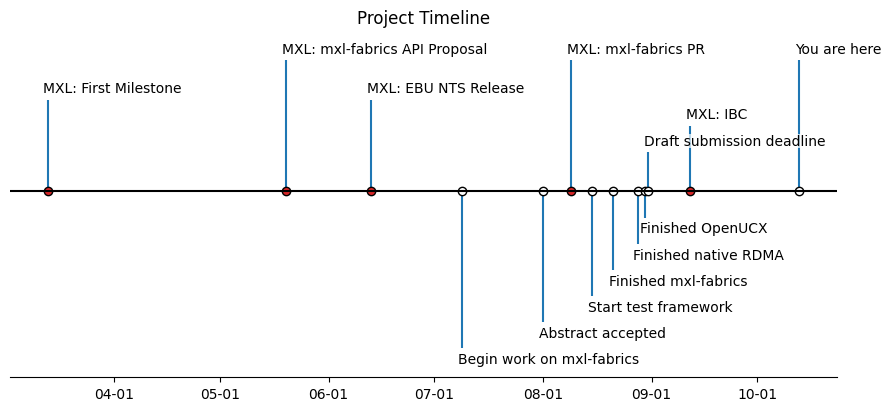

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from datetime import datetime

data = [
    {"text": "MXL: First Milestone", "date": "03-13", "level": 0.7},
    {"text": "MXL: EBU NTS Release", "date": "06-13", "level": 0.7},
    {"text": "MXL: mxl-fabrics API Proposal", "date": "05-20", "level": 1},
    {"text": "MXL: mxl-fabrics PR", "date": "08-09", "level": 1},
    {"text": "MXL: IBC", "date": "09-12", "level": 0.5},
    {"text": "Abstract accepted", "date": "08-01", "level": -1},
    {"text": "Begin work on mxl-fabrics", "date": "07-09", "level": -1.2},
    {"text": "Start test framework", "date": "08-15", "level": -0.8},
    {"text": "Finished mxl-fabrics", "date": "08-21", "level": -0.6},
    {"text": "Finished native RDMA", "date": "08-28", "level": -0.4},
    {"text": "Finished OpenUCX", "date": "08-30", "level": -0.2},
    {"text": "Draft submission deadline", "date": "08-31", "level": 0.3},
    {"text": "You are here", "date": "10-13", "level": 1},
]

events = [item["text"] for item in data]
dates = [datetime.strptime(f"2025-{item["date"]}", "%Y-%m-%d") for item in data]
levels = [item["level"] for item in data]

def is_mxl_event(str):
    return str.startswith("MXL:")

fig, ax = plt.subplots(figsize=(8.8, 4), layout="constrained")
ax.set(title="Project Timeline")
ax.vlines(dates, 0, levels)

mxl_dates = [date for date, release in zip(dates, events) if is_mxl_event(release)]
riedel_dates = [date for date, release in zip(dates, events)
               if not is_mxl_event(release)]
ax.plot(riedel_dates, np.zeros_like(riedel_dates), "ko", mfc="white")
ax.plot(mxl_dates, np.zeros_like(mxl_dates), "ko", mfc="tab:red")

for date, level, event in zip(dates, levels, events):
    ax.annotate(event, xy=(date, level),
                xytext=(-3, np.sign(level)*3), textcoords="offset points",
                verticalalignment="bottom" if level > 0 else "top",
                weight="bold" if is_feature(release) else "normal",
                bbox=dict(boxstyle='square', pad=0, lw=0, fc=(1, 1, 1, 0.7)))

ax.axhline(0, c="black")

ax.xaxis.set(major_locator=mdates.MonthLocator(),
major_formatter=mdates.DateFormatter("%m-%d"))

# Remove the y-axis and some spines.
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)

ax.margins(y=0.1)
plt.show()
